## Model Training

### Importing Libraries

In [1]:
# basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# modelling imports
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso 
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [24]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

In [25]:
print(train.shape)
print(test.shape)

(800, 8)
(200, 8)


In [26]:
X_train = train.drop(columns=['math_score'])
X_test = test.drop(columns=['math_score'])

In [27]:
X_train.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group D,master's degree,standard,none,70,75
1,female,group C,bachelor's degree,free/reduced,completed,83,83
2,female,group D,some college,free/reduced,none,89,86
3,male,group C,master's degree,free/reduced,none,67,66
4,male,group E,high school,standard,none,64,57


In [28]:
y_train = train['math_score']
y_test = test['math_score']

In [29]:
y_test

0      91
1      53
2      80
3      74
4      84
       ..
195    52
196    62
197    74
198    65
199    61
Name: math_score, Length: 200, dtype: int64

In [34]:
# Create Column Transformer with 3 types of transformers

def fun_transform(dataset):
    num_features = dataset.select_dtypes(exclude='str').columns 
    cat_features = dataset.select_dtypes(include='str').columns

    numeric_transformer = StandardScaler()
    oh_transformer = OneHotEncoder()

    preprocessor = ColumnTransformer(
        [
            ('OneHotEncoder', oh_transformer, cat_features),
            ("StandardScaler", numeric_transformer, num_features)
        ]
    )
    
    dataset = preprocessor.fit_transform(dataset)

    return dataset

In [35]:
X_train = fun_transform(X_train)
X_test = fun_transform(X_test)

scaler = StandardScaler()
y_train = scaler.fit_transform(y_train.to_frame())
y_test = scaler.transform(y_test.to_frame())

In [36]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 19)
(200, 19)
(800, 1)
(200, 1)


### Crate an Evaluate Function to give all metrics after model Training

In [11]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_scoree = r2_score(true, predicted)
    return mae, rmse, r2_scoree

In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'K-Neighbors Regressor': KNeighborsRegressor(),
    'Decision Tree' : DecisionTreeRegressor(),
    'Random Forest Regressor' : RandomForestRegressor(),
    'XGBRegressor' : XGBRegressor(),
    'CatBoosting Regressor' : CatBoostRegressor(verbose=False),
    'AdaBoost Regressor' : AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train Model
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training Set')
    print(f"- Root Mean Squared Error: {model_train_rmse:.4f}")
    print(f"- Mean Absolute Error: {model_train_mae:.4f}")
    print(f"- R2 Score: {model_train_r2:.4f}")

    print('--------------------------------------')

    print('Model performance for Test Set')
    print(f"- Root Mean Squared Error: {model_test_rmse:.4f}")
    print(f"- Mean Absolute Error: {model_test_mae:.4f}")
    print(f"- R2 Score: {model_test_r2:.4f}")
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')


Linear Regression
Model performance for Training Set
- Root Mean Squared Error: 0.3545
- Mean Absolute Error: 0.2842
- R2 Score: 0.8743
--------------------------------------
Model performance for Test Set
- Root Mean Squared Error: 0.3867
- Mean Absolute Error: 0.3052
- R2 Score: 0.8614


Lasso
Model performance for Training Set
- Root Mean Squared Error: 1.0000
- Mean Absolute Error: 0.7957
- R2 Score: 0.0000
--------------------------------------
Model performance for Test Set
- Root Mean Squared Error: 1.0477
- Mean Absolute Error: 0.8218
- R2 Score: -0.0170


Ridge
Model performance for Training Set
- Root Mean Squared Error: 0.3545
- Mean Absolute Error: 0.2841
- R2 Score: 0.8743
--------------------------------------
Model performance for Test Set
- Root Mean Squared Error: 0.3866
- Mean Absolute Error: 0.3049
- R2 Score: 0.8615


K-Neighbors Regressor
Model performance for Training Set
- Root Mean Squared Error: 0.3795
- Mean Absolute Error: 0.3000
- R2 Score: 0.8560
----------

d:\Coding\Data science\mlproject\venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Regressor
Model performance for Training Set
- Root Mean Squared Error: 0.1520
- Mean Absolute Error: 0.1216
- R2 Score: 0.9769
--------------------------------------
Model performance for Test Set
- Root Mean Squared Error: 0.4231
- Mean Absolute Error: 0.3303
- R2 Score: 0.8342


XGBRegressor
Model performance for Training Set
- Root Mean Squared Error: 0.0668
- Mean Absolute Error: 0.0452
- R2 Score: 0.9955
--------------------------------------
Model performance for Test Set
- Root Mean Squared Error: 0.4375
- Mean Absolute Error: 0.3502
- R2 Score: 0.8227


CatBoosting Regressor
Model performance for Training Set
- Root Mean Squared Error: 0.2026
- Mean Absolute Error: 0.1602
- R2 Score: 0.9589
--------------------------------------
Model performance for Test Set
- Root Mean Squared Error: 0.4230
- Mean Absolute Error: 0.3210
- R2 Score: 0.8342




d:\Coding\Data science\mlproject\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


AdaBoost Regressor
Model performance for Training Set
- Root Mean Squared Error: 0.3845
- Mean Absolute Error: 0.3148
- R2 Score: 0.8522
--------------------------------------
Model performance for Test Set
- Root Mean Squared Error: 0.4332
- Mean Absolute Error: 0.3440
- R2 Score: 0.8262




In [14]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2 Score']).sort_values(by=['R2 Score'], ascending=False)

,Model Name,R2 Score
2,Ridge,0.861534
0,Linear Regression,0.861426
7,CatBoosting Regressor,0.834246
5,Random Forest Regressor,0.834170
8,AdaBoost Regressor,0.826173
6,XGBRegressor,0.822676
3,K-Neighbors Regressor,0.755141
4,Decision Tree,0.728501
1,Lasso,-0.017039


In [16]:
ridge_model = Ridge(fit_intercept=True)
ridge_model = ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(f"Accuracy of the model is {score:.2f} : ")

Accuracy of the model is 86.15 : 


Text(0, 0.5, 'Predicted')

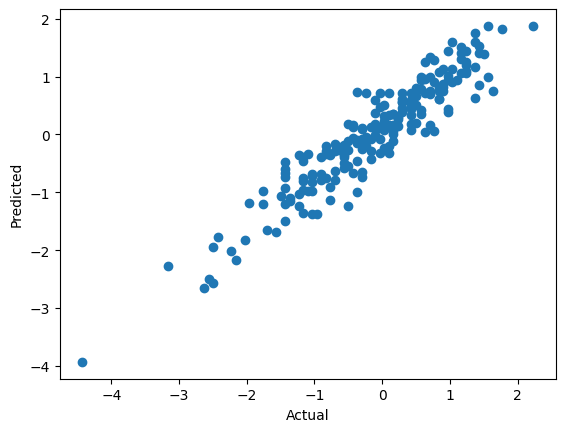

In [17]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: >

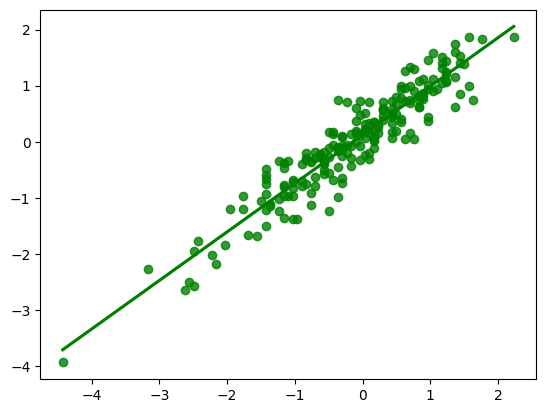

In [18]:
sns.regplot(x=y_test, y=y_pred, ci=None, color='green')

In [22]:
pred_df = pd.DataFrame({'Actual Value' : y_test.ravel(), 'Predicted Value' : y_pred.ravel(), 'Difference' : y_test.ravel()-y_pred.ravel()})
pred_df

,Actual Value,Predicted Value,Difference
0,1.631961,0.750655,0.881306
1,-0.898857,-0.390592,-0.508265
2,0.899356,0.814992,0.084364
3,0.499753,0.798667,-0.298914
4,1.165758,1.507818,-0.342060
...,...,...,...
195,-0.965457,-1.383903,0.418446
196,-0.299452,-0.135161,-0.164291
197,0.499753,0.199504,0.300249
198,-0.099651,0.148279,-0.247930
